# 🌾 India Crop Yield Prediction — Notebook 5: Hyperparameter Tuning

**Goal:** Tune the best model from Notebook 4 using **RandomizedSearchCV** and **Optuna** (optional) to maximize R² on the validation set.

---

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from scipy.stats import randint, uniform

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False
    print('Optuna not installed. Run: pip install optuna')

warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## 2. Load Data

In [2]:
X_train = pd.read_csv('processed/X_train_raw.csv')
X_val   = pd.read_csv('processed/X_val_raw.csv')
X_test  = pd.read_csv('processed/X_test_raw.csv')
y_train = pd.read_csv('processed/y_train.csv').squeeze()
y_val   = pd.read_csv('processed/y_val.csv').squeeze()
y_test  = pd.read_csv('processed/y_test.csv').squeeze()

# Combine train+val for tuning cross-validation
X_tv = pd.concat([X_train, X_val], ignore_index=True)
y_tv = pd.concat([y_train, y_val], ignore_index=True)

print(f'Train+Val for tuning: {X_tv.shape}')

Train+Val for tuning: (14753, 16)


## 3. Cross-Validation Setup

In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(r2_score)

# Baseline CV score (Random Forest with defaults)
baseline_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(baseline_rf, X_tv, y_tv, cv=kf, scoring='r2', n_jobs=-1)
print(f'Baseline RF  CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Baseline RF  CV R²: 0.9532 ± 0.0043


## 4. RandomizedSearchCV — Random Forest

In [4]:
rf_param_dist = {
    'n_estimators':     randint(100, 600),
    'max_depth':        [None, 10, 15, 20, 25, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 15),
    'max_features':     ['sqrt', 'log2', 0.5, 0.7],
    'bootstrap':        [True, False]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=40,
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print('Running RandomizedSearchCV for Random Forest')
rf_search.fit(X_tv, y_tv)

print(f'\nBest CV R²: {rf_search.best_score_:.4f}')
print(f'Best params: {rf_search.best_params_}')

Running RandomizedSearchCV for Random Forest
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV R²: 0.9478
Best params: {'bootstrap': False, 'max_depth': 20, 'max_features': 0.7, 'min_samples_leaf': 4, 'min_samples_split': 12, 'n_estimators': 227}


## 5. RandomizedSearchCV — XGBoost 

In [6]:
if HAS_XGB:
    xgb_param_dist = {
        'n_estimators':    randint(200, 800),
        'max_depth':       randint(3, 10),
        'learning_rate':   uniform(0.01, 0.2),
        'subsample':       uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_alpha':       uniform(0, 2),
        'reg_lambda':      uniform(0.5, 3),
        'min_child_weight': randint(1, 10)
    }

    xgb_search = RandomizedSearchCV(
        XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        param_distributions=xgb_param_dist,
        n_iter=40,
        cv=kf,
        scoring='r2',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    print('Running RandomizedSearchCV for XGBoost...')
    xgb_search.fit(X_tv, y_tv)

    print(f'\nBest CV R²: {xgb_search.best_score_:.4f}')
    print(f'Best params: {xgb_search.best_params_}')
else:
    xgb_search = None
    print('XGBoost not installed')

Running RandomizedSearchCV for XGBoost...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV R²: 0.9615
Best params: {'colsample_bytree': 0.878206434570451, 'learning_rate': 0.03786629088117514, 'max_depth': 9, 'min_child_weight': 4, 'n_estimators': 724, 'reg_alpha': 0.15395981965758598, 'reg_lambda': 1.369254358741304, 'subsample': 0.6644885149016018}


## 6. Optuna Bayesian Optimization (if installed)

Running Optuna optimization (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best Optuna trial R²: 0.9609
Best params: {'n_estimators': 627, 'max_depth': 9, 'learning_rate': 0.06374683132208529, 'subsample': 0.7632064121926223, 'colsample_bytree': 0.9664742858088841, 'reg_alpha': 0.1767032454270384, 'reg_lambda': 0.7516737736835138, 'min_child_weight': 2}


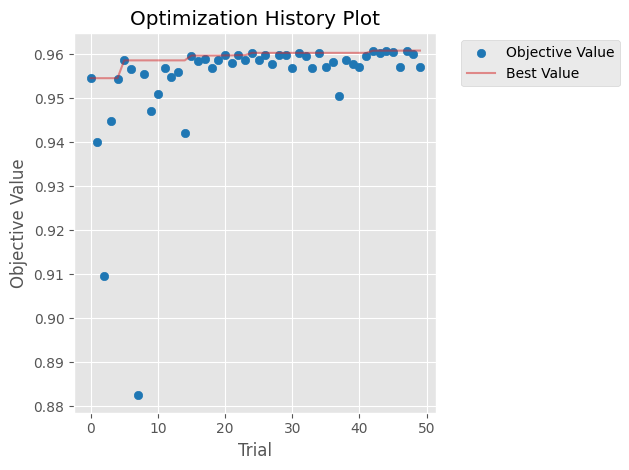

In [7]:
if HAS_OPTUNA and HAS_XGB:
    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 200, 1000),
            'max_depth':        trial.suggest_int('max_depth', 3, 10),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 3.0),
            'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 5.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        }
        model = XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0)
        scores = cross_val_score(model, X_tv, y_tv, cv=kf, scoring='r2', n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(direction='maximize')
    print('Running Optuna optimization (50 trials)...')
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    print(f'\nBest Optuna trial R²: {study.best_value:.4f}')
    print(f'Best params: {study.best_params}')

    # Optuna visualization
    try:
        from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
        fig = plot_optimization_history(study)
        plt.savefig('optuna_history.png')
        plt.show()
    except Exception:
        pass
else:
    print('Optuna or XGBoost not available')
    study = None

## 7. Select & Train Final Tuned Model

In [8]:
# Compare all tuned models
candidates = {'RF (Tuned)': rf_search.best_estimator_}

if xgb_search:
    candidates['XGB (Tuned)'] = xgb_search.best_estimator_

if study and HAS_XGB:
    optuna_xgb = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1, verbosity=0)
    optuna_xgb.fit(X_tv, y_tv)
    candidates['XGB (Optuna)'] = optuna_xgb

print('Evaluating tuned models on held-out TEST set:\n')
best_r2 = -np.inf
best_final = None
best_final_name = ''

for name, model in candidates.items():
    preds = model.predict(X_test)
    r2   = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f'  {name:20s}  Test R²={r2:.4f}  Test RMSE={rmse:.4f}')
    if r2 > best_r2:
        best_r2, best_final, best_final_name = r2, model, name

print(f'\n🏆 Best tuned model: {best_final_name}  (Test R² = {best_r2:.4f})')

Evaluating tuned models on held-out TEST set:

  RF (Tuned)            Test R²=0.9582  Test RMSE=0.2758
  XGB (Tuned)           Test R²=0.9663  Test RMSE=0.2475
  XGB (Optuna)          Test R²=0.9659  Test RMSE=0.2492

🏆 Best tuned model: XGB (Tuned)  (Test R² = 0.9663)


## 8. CV Score Distribution of Best Tuned Model

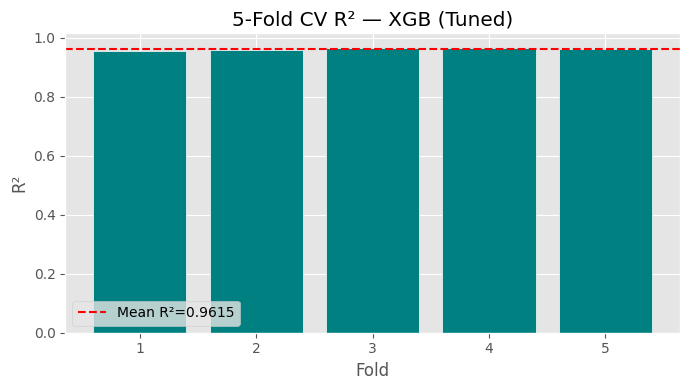

CV R²: 0.9615 ± 0.0047


In [9]:
final_cv_scores = cross_val_score(best_final, X_tv, y_tv, cv=kf, scoring='r2', n_jobs=-1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), final_cv_scores, color='teal', edgecolor='white')
ax.axhline(final_cv_scores.mean(), color='red', linestyle='--', label=f'Mean R²={final_cv_scores.mean():.4f}')
ax.set_title(f'5-Fold CV R² — {best_final_name}')
ax.set_xlabel('Fold')
ax.set_ylabel('R²')
ax.legend()
plt.tight_layout()
plt.savefig('cv_scores_tuned.png')
plt.show()

print(f'CV R²: {final_cv_scores.mean():.4f} ± {final_cv_scores.std():.4f}')

## 9. Save Final Tuned Model

In [10]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(best_final, 'models/final_tuned_model.pkl')

# Save tuning summary
tuning_summary = {
    'best_model_name': best_final_name,
    'test_r2': float(best_r2),
    'cv_r2_mean': float(final_cv_scores.mean()),
    'cv_r2_std': float(final_cv_scores.std())
}
with open('models/tuning_summary.json', 'w') as f:
    json.dump(tuning_summary, f, indent=2)

print(f'Final tuned model saved: models/final_tuned_model.pkl')
print(f'Tuning summary saved:   models/tuning_summary.json')

Final tuned model saved: models/final_tuned_model.pkl
Tuning summary saved:   models/tuning_summary.json


---
✅ **Tuning complete.** Proceed to `06_model_evaluation.ipynb`.